In [67]:
from google.colab import drive
drive.mount('/content/drive')


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob

ruta = '/content/drive/MyDrive/INDEC/'

archivos = glob.glob(ruta + 'usu_individual_T*.txt')

dataframes = {}
for archivo in sorted(archivos):
    nombre = os.path.basename(archivo)
    try:
        df = pd.read_csv(archivo, sep=';', encoding='utf-8', low_memory=False)
    except:
        df = pd.read_csv(archivo, sep=';', encoding='latin-1', low_memory=False)
    dataframes[nombre] = df
    print(f"✅ {nombre}: {df.shape[0]:,} filas")

df_total = pd.concat(dataframes.values(), ignore_index=True)
print(f"\n📊 Total: {df_total.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ usu_individual_T119.txt: 59,369 filas
✅ usu_individual_T120.txt: 51,643 filas
✅ usu_individual_T121.txt: 46,693 filas
✅ usu_individual_T122.txt: 49,706 filas
✅ usu_individual_T123.txt: 48,638 filas
✅ usu_individual_T124.txt: 46,050 filas
✅ usu_individual_T125.txt: 45,425 filas
✅ usu_individual_T219.txt: 59,258 filas
✅ usu_individual_T220.txt: 37,132 filas
✅ usu_individual_T221.txt: 47,085 filas
✅ usu_individual_T222.txt: 50,614 filas
✅ usu_individual_T223.txt: 49,072 filas
✅ usu_individual_T224.txt: 47,151 filas
✅ usu_individual_T225.txt: 46,086 filas
✅ usu_individual_T319.txt: 57,229 filas
✅ usu_individual_T320.txt: 41,685 filas
✅ usu_individual_T321.txt: 48,668 filas
✅ usu_individual_T322.txt: 49,232 filas
✅ usu_individual_T323.txt: 48,335 filas
✅ usu_individual_T324.txt: 47,564 filas
✅ usu_individual_T325.txt: 44,946 filas
✅ usu_individual_T419.txt: 58,5

# Celda 2 — Renombrar y seleccionar columnas:
De las 240 columnas originales de la EPH, selecciona solo las 14 que necesitás y les cambia el nombre del código técnico del INDEC al español descriptivo.

In [68]:
#Celda 2 — Renombrar y seleccionar columnas
renombrar = {
    'ANO4'       : 'anio',
    'TRIMESTRE'  : 'trimestre',
    'REGION'     : 'region',
    'AGLOMERADO' : 'aglomerado',
    'PONDERA'    : 'ponderacion',
    'ESTADO'     : 'condicion_laboral',
    'CAT_OCUP'   : 'categoria_ocupacion',
    'CAT_INAC'   : 'tipo_inactividad',
    'PP07H'      : 'descuento_jubilatorio',
    'PP07E'      : 'antiguedad_en_trabajo',
    'CH04'       : 'sexo',
    'CH06'       : 'edad',
    'NIVEL_ED'   : 'nivel_educativo',
    'ITF'        : 'ingreso_total_familiar'

}

columnas_a_mantener = list(renombrar.values())
df_total.rename(columns=renombrar, inplace=True)
df_total = df_total[[c for c in columnas_a_mantener if c in df_total.columns]]

print(f"✅ Columnas finales ({len(df_total.columns)}): {df_total.columns.tolist()}")
print(f"📊 Shape: {df_total.shape}")

✅ Columnas finales (14): ['anio', 'trimestre', 'region', 'aglomerado', 'ponderacion', 'condicion_laboral', 'categoria_ocupacion', 'tipo_inactividad', 'descuento_jubilatorio', 'antiguedad_en_trabajo', 'sexo', 'edad', 'nivel_educativo', 'ingreso_total_familiar']
📊 Shape: (1316763, 14)


In [69]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1316763 entries, 0 to 1316762
Data columns (total 14 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   anio                    1316763 non-null  int64  
 1   trimestre               1316763 non-null  int64  
 2   region                  1316763 non-null  int64  
 3   aglomerado              1316763 non-null  int64  
 4   ponderacion             1316763 non-null  int64  
 5   condicion_laboral       1316763 non-null  int64  
 6   categoria_ocupacion     1316763 non-null  int64  
 7   tipo_inactividad        1316763 non-null  int64  
 8   descuento_jubilatorio   560956 non-null   float64
 9   antiguedad_en_trabajo   560956 non-null   float64
 10  sexo                    1316763 non-null  int64  
 11  edad                    1316763 non-null  int64  
 12  nivel_educativo         1316763 non-null  int64  
 13  ingreso_total_familiar  1316761 non-null  object 
dtypes:

# Celda 3 — Filtrar población en edad de trabajar:
Elimina todos los menores de 15 años porque no son población objetivo del análisis laboral. Resetea el índice para que quede limpio.

In [70]:

df_total = df_total[df_total['edad'] >= 15].copy()
df_total = df_total.reset_index(drop=True)

print(f"✅ Filas después de filtrar menores de 15: {len(df_total):,}")

✅ Filas después de filtrar menores de 15: 1,045,045


# Celda 4 — Rango de edad:
Crea una nueva columna agrupando la edad en 5 franjas: 15-18, 19-24, 25-35, 36-60 y +60, útiles para el análisis de desempleo juvenil y reingreso de mayores.




In [71]:

#bins   = [14, 18, 24, 35, 45, 60, 70, 75, 999]
#labels = ['15-18', '19-24', '25-35', '36-45', '46-60', '61-70', '71-75', '+76']
bins   = [14, 18, 24, 35, 45, 60, 65, 999]
labels = ['15-18', '19-24', '25-35', '36-45', '46-60', '61-65', '65+']

df_total['rango_edad'] = pd.cut(df_total['edad'], bins=bins, labels=labels)

print(df_total['rango_edad'].value_counts().sort_index())
print(f"NaN en rango_edad: {df_total['rango_edad'].isna().sum():,}")



rango_edad
15-18     85515
19-24    129257
25-35    210319
36-45    178935
46-60    218909
61-65     63136
65+      158974
Name: count, dtype: int64
NaN en rango_edad: 0


# Celda 5 — Etiquetas categóricas:
Celda 5 — Etiquetas categóricas
Convierte los códigos numéricos del INDEC a texto legible en todas las variables categóricas: sexo, nivel educativo, condición laboral, categoría de ocupación, tipo de inactividad, descuento jubilatorio y antigüedad.

In [72]:

df_total['sexo'] = df_total['sexo'].map({
    1: 'Varón',
    2: 'Mujer'
})

df_total['nivel_educativo'] = df_total['nivel_educativo'].map({
    1: 'Primaria incompleta',
    2: 'Primaria completa',
    3: 'Secundaria incompleta',
    4: 'Secundaria completa',
    5: 'Superior/Univ. incompleto',
    6: 'Superior/Univ. completo',
    7: 'Sin instrucción',
    9: 'Ns/Nc'
})

df_total['condicion_laboral'] = df_total['condicion_laboral'].map({
    1: 'Ocupado',
    2: 'Desocupado',
    3: 'Inactivo',
    4: 'Menor de 10 años'
})

df_total['categoria_ocupacion'] = df_total['categoria_ocupacion'].map({
    0: 'No aplica',
    1: 'Patrón/Empleador',
    2: 'Cuenta propia',
    3: 'Asalariado',
    4: 'Familiar sin pago'
})

df_total['tipo_inactividad'] = df_total['tipo_inactividad'].map({
    0: 'No aplica',
    1: 'Jubilado/Pensionado',
    2: 'Rentista',
    3: 'Ama de casa',
    4: 'Estudiante',
    5: 'Discapacitado',
    6: 'Otro inactivo'
})

df_total['descuento_jubilatorio'] = df_total['descuento_jubilatorio'].map({
    1.0: 'Con descuento',
    2.0: 'Sin descuento',
    9.0: 'Ns/Nc'
})

df_total['antiguedad_en_trabajo'] = df_total['antiguedad_en_trabajo'].map({
    1.0: 'Menos de 1 mes',
    2.0: '1 a 3 meses',
    3.0: '3 a 6 meses',
    4.0: '6 a 12 meses',
    5.0: '1 a 5 años',
    6.0: 'Más de 5 años',
    9.0: 'Ns/Nc'
})

print("✅ Etiquetas aplicadas")

✅ Etiquetas aplicadas


# Celda 6 — Región y aglomerado:
Convierte los códigos numéricos de región y aglomerado a sus nombres geográficos reales (ej: 43 → 'Pampeana', 34 → 'Mar del Plata - Batán').

In [73]:
df_total['region'] = df_total['region'].map({
    1:  'GBA',
    40: 'NOA',
    41: 'NEA',
    42: 'Cuyo',
    43: 'Pampeana',
    44: 'Patagónica'
})

df_total['aglomerado'] = df_total['aglomerado'].map({
    2:  'Gran La Plata',
    3:  'Bahía Blanca',
    4:  'Gran Rosario',
    5:  'Gran Santa Fe',
    6:  'Gran Paraná',
    7:  'Posadas',
    8:  'Gran Resistencia',
    9:  'Comodoro Rivadavia',
    10: 'Gran Mendoza',
    12: 'Corrientes',
    13: 'Gran Córdoba',
    14: 'Concordia',
    15: 'Formosa',
    17: 'Neuquén-Plottier',
    18: 'Santiago del Estero-La Banda',
    19: 'Jujuy-Palpalá',
    20: 'Río Gallegos',
    22: 'Gran Catamarca',
    23: 'Gran Salta',
    25: 'La Rioja',
    26: 'San Luis-El Chorrillo',
    27: 'Gran San Juan',
    29: 'Gran Tucumán',
    30: 'Santa Rosa-Toay',
    31: 'Ushuaia-Río Grande',
    32: 'Ciudad de Bs As',
    33: 'Partidos del GBA',
    34: 'Mar del Plata - Batán',
    36: 'Río Cuarto',
    38: 'San Nicolás-Villa Constitución',
    91: 'Rawson-Trelew',
    93: 'Viedma-Carmen de Patagones'
})

print(df_total['region'].value_counts())
print(df_total['aglomerado'].value_counts())

region
Pampeana      320774
NOA           225608
GBA           153450
Patagónica    127765
Cuyo          110530
NEA           106918
Name: count, dtype: int64
aglomerado
Partidos del GBA                  117784
Gran Salta                         47320
Gran Córdoba                       44243
Gran Mendoza                       44227
Gran Tucumán                       43701
Gran Rosario                       38555
Gran San Juan                      36941
Ciudad de Bs As                    35666
Jujuy-Palpalá                      35659
Santiago del Estero-La Banda       33735
La Rioja                           32611
Gran Catamarca                     32582
Gran Santa Fe                      31711
San Nicolás-Villa Constitución     31220
Concordia                          31210
Gran Paraná                        30907
San Luis-El Chorrillo              29362
Formosa                            28443
Gran Resistencia                   26462
Posadas                            26164
Corrientes

# Celda 7 — Limpiar NaN de antigüedad:
Asigna 'No aplica' a quienes no trabajan o no son asalariados, y 'Ns/Nc' a asalariados que no respondieron. La antigüedad solo tiene sentido para asalariados.

In [74]:
# Ocupados no asalariados → 'No aplica'
df_total.loc[
    (df_total['condicion_laboral'] == 'Ocupado') &
    (df_total['categoria_ocupacion'] != 'Asalariado'),
    'antiguedad_en_trabajo'
] = 'No aplica'

# No ocupados → 'No aplica'
df_total.loc[
    df_total['condicion_laboral'] != 'Ocupado',
    'antiguedad_en_trabajo'
] = 'No aplica'

# Asalariados sin respuesta → 'Ns/Nc'
df_total['antiguedad_en_trabajo'] = df_total['antiguedad_en_trabajo'].fillna('Ns/Nc')

print(df_total['antiguedad_en_trabajo'].value_counts(dropna=False))

antiguedad_en_trabajo
No aplica         633510
Ns/Nc             338394
6 a 12 meses       58913
Menos de 1 mes      7148
1 a 3 meses         4405
3 a 6 meses         2675
Name: count, dtype: int64


# Celda 8 — Limpiar NaN de descuento jubilatorio:
Misma lógica que antigüedad — asigna 'No aplica' a no ocupados y no asalariados, y 'Ns/Nc' a asalariados sin respuesta.


In [75]:
# No ocupados → 'No aplica'
df_total.loc[
    df_total['condicion_laboral'] != 'Ocupado',
    'descuento_jubilatorio'
] = 'No aplica'

# Ocupados no asalariados → 'No aplica'
df_total.loc[
    (df_total['condicion_laboral'] == 'Ocupado') &
    (df_total['categoria_ocupacion'] != 'Asalariado'),
    'descuento_jubilatorio'
] = 'No aplica'

# Asalariados sin respuesta → 'Ns/Nc'
df_total.loc[
    (df_total['condicion_laboral'] == 'Ocupado') &
    (df_total['categoria_ocupacion'] == 'Asalariado') &
    (df_total['descuento_jubilatorio'].isna()),
    'descuento_jubilatorio'
] = 'Ns/Nc'

# ← AGREGAR ESTA LÍNEA
df_total.loc[
    (df_total['categoria_ocupacion'] == 'Asalariado') &
    (df_total['descuento_jubilatorio'] == 'No aplica'),
    'descuento_jubilatorio'
] = 'Ns/Nc'

print(df_total['descuento_jubilatorio'].value_counts(dropna=False))

descuento_jubilatorio
No aplica        609663
Con descuento    265122
Sin descuento    146413
Ns/Nc             23847
Name: count, dtype: int64


# Celda 9 — Crear situacion_registro:
Construye una nueva columna que clasifica a cada persona en 'Blanco/Registrado', 'Negro/Informal' o 'No Asalariado' cruzando categoría de ocupación y descuento jubilatorio.

In [76]:
def clasificar_registro(row):
    if row['categoria_ocupacion'] == 'Asalariado':
        if row['descuento_jubilatorio'] == 'Con descuento':
            return 'Blanco/Registrado'
        elif row['descuento_jubilatorio'] == 'Sin descuento':
            return 'Negro/Informal'
        else:
            return 'Ns/Nc'  # ← asalariados sin respuesta
    return 'No Asalariado'

df_total['situacion_registro'] = df_total.apply(clasificar_registro, axis=1)

print(df_total['situacion_registro'].value_counts())
print(df_total[df_total['categoria_ocupacion'] == 'Asalariado']['situacion_registro'].value_counts())

situacion_registro
No Asalariado        609663
Blanco/Registrado    265122
Negro/Informal       146413
Ns/Nc                 23847
Name: count, dtype: int64
situacion_registro
Blanco/Registrado    265122
Negro/Informal       146413
Ns/Nc                 23847
Name: count, dtype: int64


Celda 10 — Verificación final:


In [77]:
print(f"📊 Shape final: {df_total.shape}")
print(f"📅 Períodos: {sorted(df_total['anio'].unique())}")
print(f"\n🔍 NaN por columna:")
print(df_total.isnull().sum())
print(f"\n📋 Columnas: {df_total.columns.tolist()}")
print(df_total.head(3))

📊 Shape final: (1045045, 16)
📅 Períodos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

🔍 NaN por columna:
anio                          0
trimestre                     0
region                        0
aglomerado                    0
ponderacion                   0
condicion_laboral          1770
categoria_ocupacion          38
tipo_inactividad          22810
descuento_jubilatorio         0
antiguedad_en_trabajo         0
sexo                          0
edad                          0
nivel_educativo               0
ingreso_total_familiar        2
rango_edad                    0
situacion_registro            0
dtype: int64

📋 Columnas: ['anio', 'trimestre', 'region', 'aglomerado', 'ponderacion', 'condicion_laboral', 'categoria_ocupacion', 'tipo_inactividad', 'descuento_jubilatorio', 'antiguedad_en_trabajo', 'sexo', 'edad', 'nivel_educativo', 'ingreso_total_familiar', 'rango_edad', 'situacion_registro']
   anio  trimest

In [78]:
df_total['condicion_laboral'] = df_total['condicion_laboral'].fillna('Ns/Nc')
df_total['categoria_ocupacion'] = df_total['categoria_ocupacion'].fillna('Ns/Nc')
df_total['tipo_inactividad'] = df_total['tipo_inactividad'].fillna('No aplica')

print(df_total.isnull().sum())

anio                      0
trimestre                 0
region                    0
aglomerado                0
ponderacion               0
condicion_laboral         0
categoria_ocupacion       0
tipo_inactividad          0
descuento_jubilatorio     0
antiguedad_en_trabajo     0
sexo                      0
edad                      0
nivel_educativo           0
ingreso_total_familiar    2
rango_edad                0
situacion_registro        0
dtype: int64


# Analisis

In [79]:
#saca el PEA(Población Económicamente Activa)
PEA = df_total[df_total['situacion_registro'] == 'Blanco/Registrado']

PEA['situacion_registro']

,situacion_registro
12,Blanco/Registrado
14,Blanco/Registrado
19,Blanco/Registrado
26,Blanco/Registrado
29,Blanco/Registrado
...,...
1045026,Blanco/Registrado
1045030,Blanco/Registrado
1045031,Blanco/Registrado
1045034,Blanco/Registrado


In [80]:
#filtra por condicion laboral
filtro_Estado    = df_total[df_total['condicion_laboral'].isin(['Ocupado', 'Desocupado'])]

In [81]:
#filtra solo desocupados
filtro_desocupados = filtro_Estado[filtro_Estado['condicion_laboral'] == 'Desocupado']

In [82]:
suma_PEA = filtro_Estado.groupby(['anio','trimestre'])['ponderacion'].sum()


In [83]:
suma_desocupados =  filtro_desocupados.groupby(['anio','trimestre'])['ponderacion'].sum()


In [84]:
#crea la columna tasa de desempleo
tasa_desempleo = (suma_desocupados / suma_PEA) * 100


In [85]:
tasa_grafico = tasa_desempleo.reset_index()


In [86]:
tasa_grafico.columns = ['anio', 'trimestre', 'tasa']

In [87]:
#crea columna periodo
tasa_grafico['periodo'] = tasa_grafico['anio'].astype(str) + ' - T' + tasa_grafico['trimestre'].astype(str)

In [88]:
tasa_grafico['tasa'] = tasa_grafico['tasa'].round(1)

In [89]:
anio_trimestre = tasa_grafico['periodo']
tasa_de_desempleo = tasa_grafico['tasa']

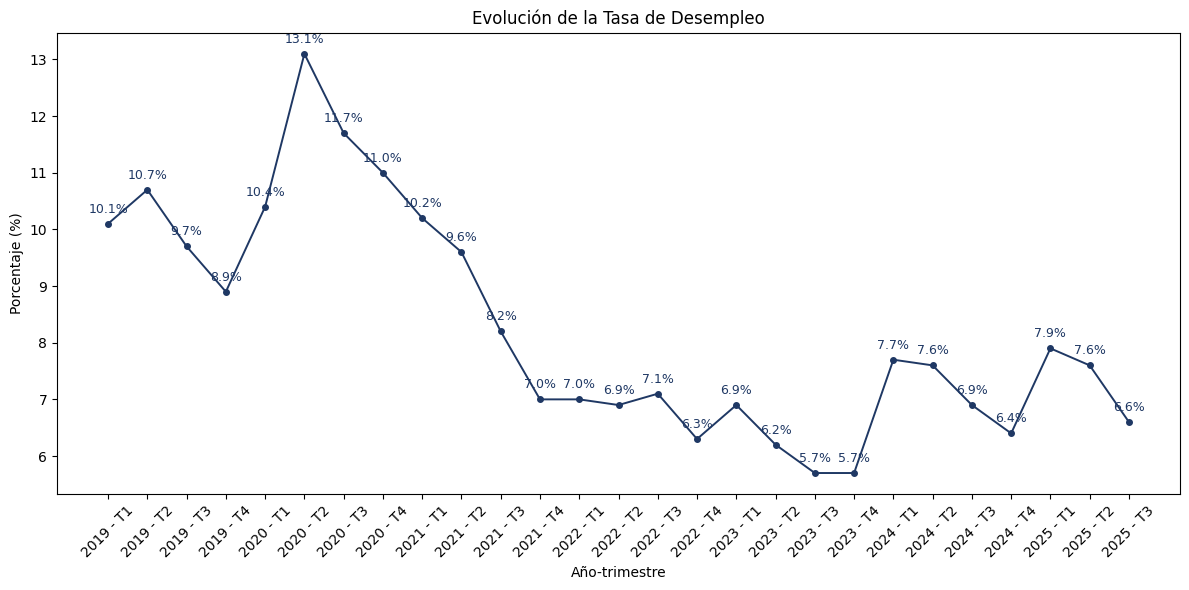

In [90]:
#Grafico
fig, ax=plt.subplots(figsize=(12, 6))

ax.plot( tasa_grafico['periodo'], tasa_grafico['tasa'], marker='o', color= '#1F3864', linewidth=1.4, markersize=4)

# Etiquetas de porcentaje en cada punto
for _, row in tasa_grafico.iterrows():
    ax.annotate(f"{row['tasa']}%", (row['periodo'], row['tasa']),
                textcoords='offset points', xytext=(0,8),
                ha='center', fontsize=9, color= '#1F3864')

ax.set_title('Evolución de la Tasa de Desempleo')
ax.set_xlabel('Año-trimestre')
ax.set_ylabel('Porcentaje (%)')
ax.tick_params(axis='x', labelrotation=45)


plt.tight_layout()
plt.show()

4 Efecto de la estacionalidad 4tos trimestres y
 Pendiente5Evolución informalidad ante inflación 2023-2024

In [91]:
#filtra por año
año_filtro = df_total[(df_total['anio'] >= 2019) & (df_total['anio'] <= 2025)]

In [92]:
#filtra solo por ocupados
ocupados = df_total[df_total['condicion_laboral'] == 'Ocupado']

In [93]:
#filtra por formales y informales
registrados = ocupados[ocupados['situacion_registro'] == 'Blanco/Registrado']
informales = ocupados[ocupados['situacion_registro'] == 'Negro/Informal']

In [94]:
#agrupa  y suma los registrados por año, trimestre y ponderacion
regis = registrados.groupby(['anio', 'trimestre'])['ponderacion'].sum() / 1e6


In [95]:
#agrupa  y suma los informales por año, trimestre y ponderacion
infor = informales.groupby(['anio', 'trimestre'])['ponderacion'].sum() / 1e6

In [96]:
regis = regis.reset_index()
infor = infor.reset_index()

In [97]:
#crear la columna periodo

regis['periodo'] = regis['anio'].astype(str)  + ' - T' + regis['trimestre'].astype(str)
infor['periodo'] = infor['anio'].astype(str)  + ' - T' + infor['trimestre'].astype(str)

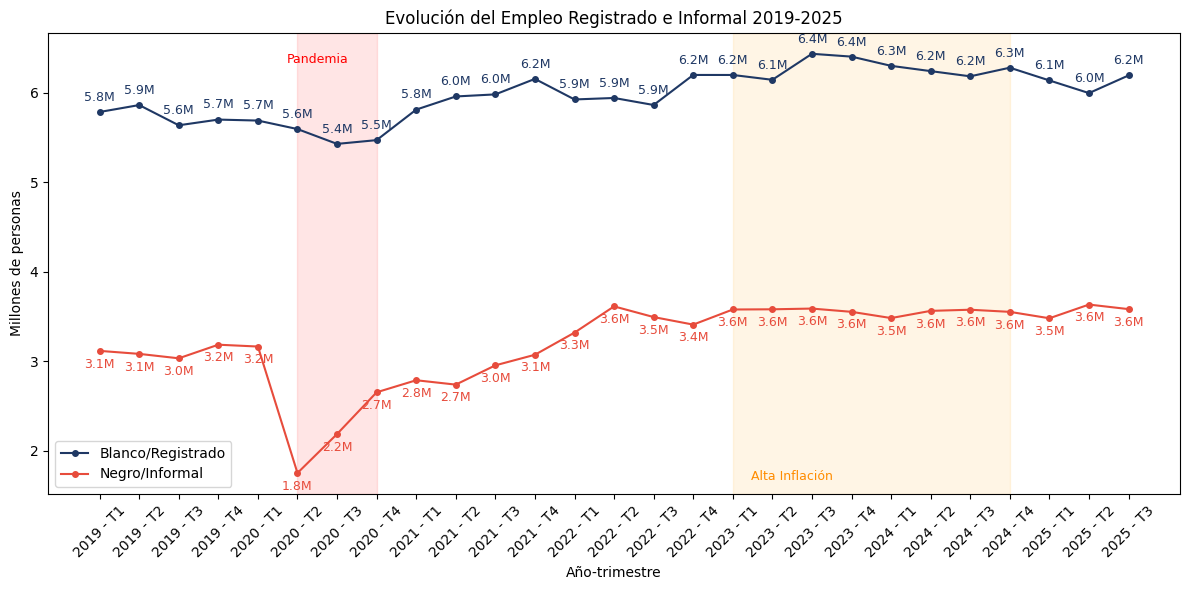

In [98]:
fix, ax=plt.subplots(figsize=(12, 6))



ax.plot(regis['periodo'], regis['ponderacion'],color='#1F3864', marker='o', linewidth=1.5, markersize=4, label='Blanco/Registrado')

ax.plot(infor['periodo'], infor['ponderacion'], color='#E74C3C', marker='o', linewidth=1.5, markersize=4, label='Negro/Informal')

# Etiquetas
for _, row in regis.iterrows():
    ax.annotate(f"{row['ponderacion']:.1f}M", (row['periodo'], row['ponderacion']),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9, color='#1F3864')

for _, row in infor.iterrows():
    ax.annotate(f"{row['ponderacion']:.1f}M", (row['periodo'], row['ponderacion']),
                textcoords='offset points', xytext=(0, -12),
                ha='center', fontsize=9, color='#E74C3C')

# Zonas sombreadas
periodos = regis['periodo'].tolist()

idx_pan_ini = periodos.index('2020 - T2')
idx_pan_fin = periodos.index('2020 - T4')
idx_inf_ini = periodos.index('2023 - T1')
idx_inf_fin = periodos.index('2024 - T4')

ax.axvspan(idx_pan_ini, idx_pan_fin, alpha=0.1, color='red')
ax.axvspan(idx_inf_ini, idx_inf_fin, alpha=0.1, color='orange')

# Anotaciones de zonas
ax.annotate('Pandemia', xy=(idx_pan_ini + 0.5, ax.get_ylim()[1] * 0.95),
            fontsize=9, color='red', ha='center')
ax.annotate('Alta Inflación', xy=(idx_inf_ini + 1.5, ax.get_ylim()[0] * 1.1),
            fontsize=9, color='darkorange', ha='center')

ax.set_title('Evolución del Empleo Registrado e Informal 2019-2025')
ax.set_xlabel('Año-trimestre')
ax.set_ylabel('Millones de personas')
ax.legend()
ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

# peso del cuentapropismo

In [99]:
#filtra solo a ocupados
solo_ocupado = df_total[df_total['condicion_laboral'] == 'Ocupado']

In [100]:
#agrupa 'anio','trimestre','categoria_ocupacion' yu sumo a ponderacion
agrupo_trim_ocupacion = solo_ocupado.groupby(['anio','trimestre','categoria_ocupacion'])['ponderacion'].sum() / 1e6

In [101]:
agrupo_trim_ocupacion = agrupo_trim_ocupacion.reset_index()

In [102]:
# crear la columna periodo
agrupo_trim_ocupacion['periodo'] = agrupo_trim_ocupacion['anio'].astype(str) + ' - T' + agrupo_trim_ocupacion['trimestre'].astype(str)

In [103]:
# reseteo con reset index
agrupo_trim_ocupacion = agrupo_trim_ocupacion.reset_index()

In [104]:
agrupo_trim_ocupacion

,index,anio,trimestre,categoria_ocupacion,ponderacion,periodo
0,0,2019,1,Asalariado,8.900206,2019 - T1
1,1,2019,1,Cuenta propia,2.542343,2019 - T1
2,2,2019,1,Familiar sin pago,0.065014,2019 - T1
3,3,2019,1,Patrón/Empleador,0.430617,2019 - T1
4,4,2019,2,Asalariado,8.944290,2019 - T2
...,...,...,...,...,...,...
103,103,2025,2,Patrón/Empleador,0.467511,2025 - T2
104,104,2025,3,Asalariado,9.775413,2025 - T3
105,105,2025,3,Cuenta propia,3.329637,2025 - T3
106,106,2025,3,Familiar sin pago,0.052387,2025 - T3


In [105]:
#separar cada categoría en su propia variable
asalariados = agrupo_trim_ocupacion[agrupo_trim_ocupacion['categoria_ocupacion'] == 'Asalariado']
cuenta_propia = agrupo_trim_ocupacion[agrupo_trim_ocupacion['categoria_ocupacion'] == 'Cuenta propia']
empleador =agrupo_trim_ocupacion[agrupo_trim_ocupacion['categoria_ocupacion'] == 'Patrón/Empleador']


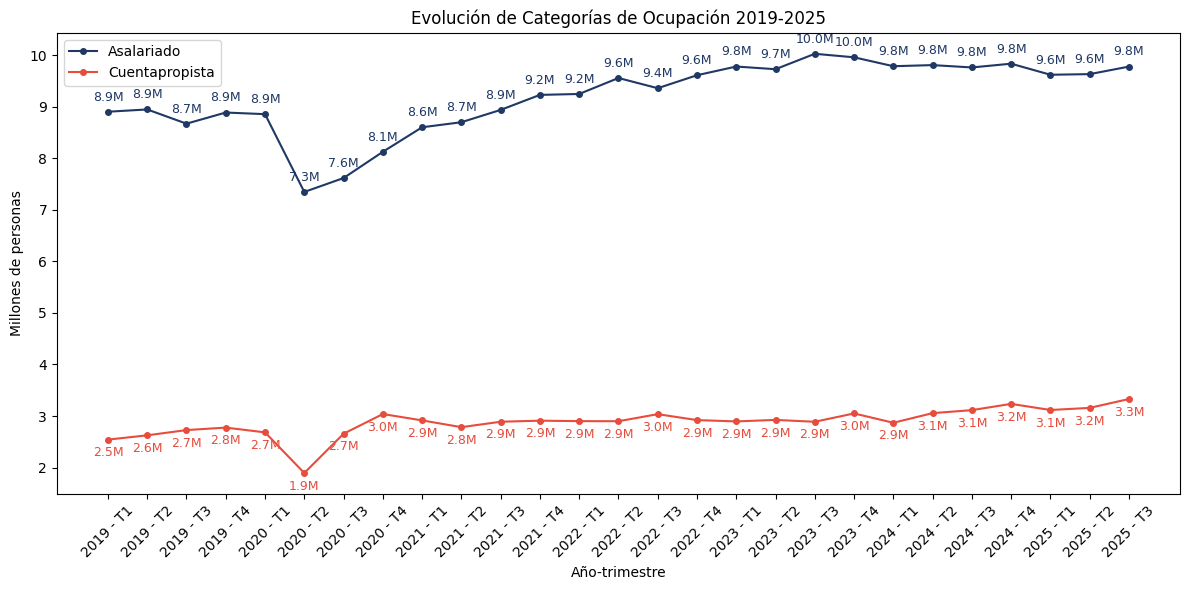

In [106]:
#Grafico
fix, ax=plt.subplots(figsize=(12, 6))



ax.plot(asalariados['periodo'], asalariados['ponderacion'],color='#1F3864', marker='o', linewidth=1.5, markersize=4, label='Asalariado')

ax.plot(cuenta_propia['periodo'], cuenta_propia['ponderacion'], color='#E74C3C', marker='o', linewidth=1.5, markersize=4, label='Cuentapropista')



# Etiquetas
for _, row in asalariados.iterrows():
    ax.annotate(f"{row['ponderacion']:.1f}M", (row['periodo'], row['ponderacion']),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9, color='#1F3864')

for _, row in cuenta_propia.iterrows():
    ax.annotate(f"{row['ponderacion']:.1f}M", (row['periodo'], row['ponderacion']),
                textcoords='offset points', xytext=(0, -12),
                ha='center', fontsize=9, color='#E74C3C')





ax.set_title('Evolución de Categorías de Ocupación 2019-2025')
ax.set_xlabel('Año-trimestre')
ax.set_ylabel('Millones de personas')
ax.legend()
ax.tick_params(axis='x', labelrotation=45)


plt.tight_layout()
plt.show()

# Educación vs Informalidad

In [107]:
#filtra solo a asalariados
filtro_asalariado = df_total[df_total['categoria_ocupacion'] == 'Asalariado']

In [108]:
#agrupa 'nivel_educativo','situacion_registro'
tabla = filtro_asalariado.groupby(['nivel_educativo','situacion_registro'])['ponderacion'].sum() / 1e6

In [109]:
tabla = tabla.unstack()

In [110]:
#calcula el porcentaje
tabla['porcentaje_informalidad'] = tabla['Negro/Informal'] /(tabla['Negro/Informal']+tabla['Blanco/Registrado'])*100

In [111]:
#muestra tabla informalidad por nuvel educativo
tabla

situacion_registro,Blanco/Registrado,Negro/Informal,Ns/Nc,porcentaje_informalidad
nivel_educativo,,,,
Primaria completa,12.648814,13.106121,1.952750,50.887805
Primaria incompleta,2.071625,3.779598,0.560948,64.595009
Secundaria completa,46.501459,26.379367,5.675638,36.195209
Secundaria incompleta,17.283280,21.165389,4.480618,55.048431
Sin instrucción,0.317230,0.327375,0.030632,50.786916
Superior/Univ. completo,56.195131,9.365107,1.547008,14.284736
Superior/Univ. incompleto,26.500815,12.588872,3.259611,32.205098


In [112]:
print(df_total['nivel_educativo'].value_counts())

nivel_educativo
Secundaria completa          269769
Secundaria incompleta        224859
Superior/Univ. completo      175749
Superior/Univ. incompleto    158869
Primaria completa            155028
Primaria incompleta           53897
Sin instrucción                6874
Name: count, dtype: int64


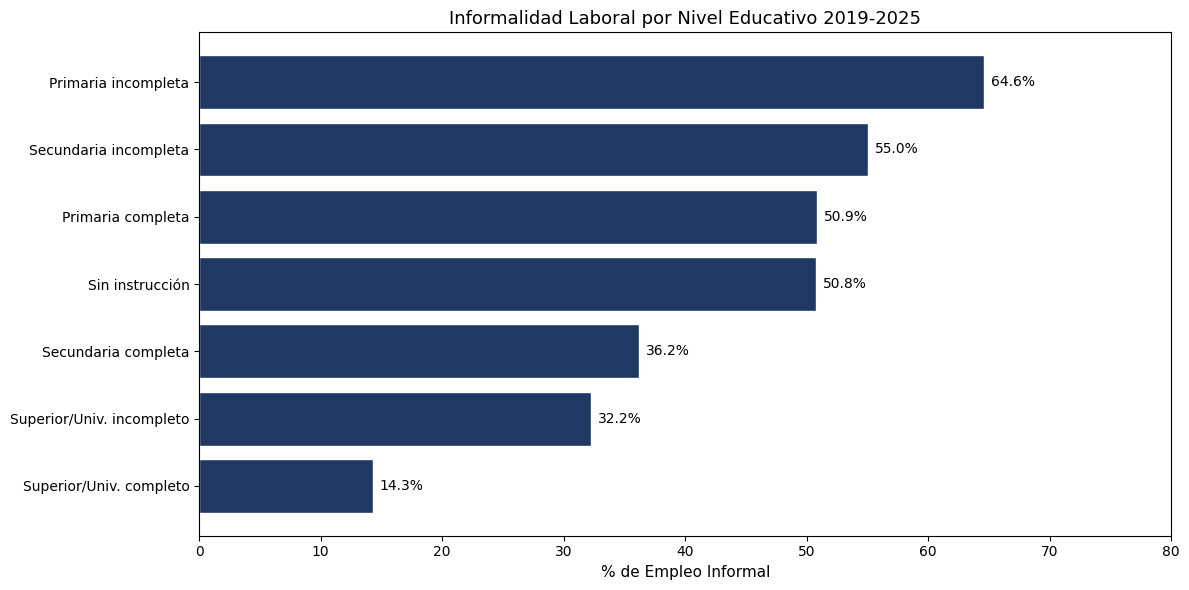

In [113]:

#Grafico
tabla_grafico = tabla[['porcentaje_informalidad']].sort_values('porcentaje_informalidad', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

barras = ax.barh(tabla_grafico.index, tabla_grafico['porcentaje_informalidad'],
                  color='#1F3864', edgecolor='white')

# Etiquetas en cada barra
for barra in barras:
    ancho = barra.get_width()
    ax.annotate(f'{ancho:.1f}%',
                xy=(ancho, barra.get_y() + barra.get_height() / 2),
                xytext=(5, 0), textcoords='offset points',
                ha='left', va='center', fontsize=10)

ax.set_title('Informalidad Laboral por Nivel Educativo 2019-2025', fontsize=13)
ax.set_xlabel('% de Empleo Informal', fontsize=11)
ax.set_xlim(0, 80)


plt.tight_layout()
plt.savefig('grafico_educacion_informalidad.png', dpi=150, bbox_inches='tight')
plt.show()

# Brecha de género en informalidad


In [114]:
#filtro solo a asalariados
#filtro_asalariado = df_total[df_total['categoria_ocupacion'] == 'Asalariado']

In [115]:
#agrupa
tabla_genero = filtro_asalariado.groupby(['sexo', 'situacion_registro'])['ponderacion'].sum() / 1e6

In [116]:
tabla_genero = tabla_genero.unstack()

In [117]:
#calcula el porcentaje
tabla_genero['porcentaje_informalidad'] = tabla_genero['Negro/Informal'] /(tabla_genero['Negro/Informal']+tabla_genero['Blanco/Registrado'])*100

In [118]:
#muestra la tabla  genero
tabla_genero

situacion_registro,Blanco/Registrado,Negro/Informal,Ns/Nc,porcentaje_informalidad
sexo,,,,
Mujer,71.343884,41.439516,8.657944,36.742567
Varón,90.174470,45.272313,8.849261,33.424428


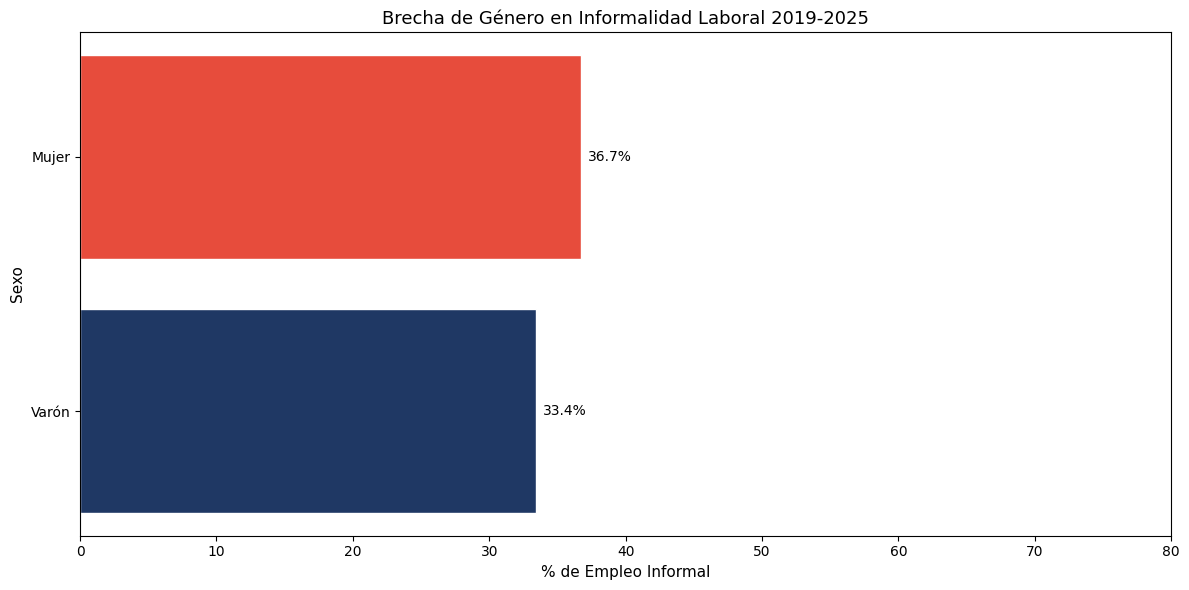

In [119]:
#Grafico
tabla_grafico = tabla_genero[['porcentaje_informalidad']].sort_values('porcentaje_informalidad', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

colores = ['#1F3864', '#E74C3C']  # Varón azul, Mujer rojo

barras = ax.barh(tabla_grafico.index, tabla_grafico['porcentaje_informalidad'],
                  color=colores, edgecolor='white')

# Etiquetas en cada barra
for barra in barras:
    ancho = barra.get_width()
    ax.annotate(f'{ancho:.1f}%',
                xy=(ancho, barra.get_y() + barra.get_height() / 2),
                xytext=(5, 0), textcoords='offset points',
                ha='left', va='center', fontsize=10)

ax.set_title('Brecha de Género en Informalidad Laboral 2019-2025', fontsize=13)
ax.set_xlabel('% de Empleo Informal', fontsize=11)
ax.set_ylabel('Sexo', fontsize=11)
ax.set_xlim(0, 80)


plt.tight_layout()
plt.savefig('grafico_informalidad_genero.png', dpi=150, bbox_inches='tight')
plt.show()

# Cicatrices Regionales

In [120]:
# PEA sin límite de edad
pea_region = df_total[(df_total['condicion_laboral'] == 'Ocupado' )  | (df_total['condicion_laboral'] == 'Desocupado')]
desoc_region = df_total[df_total['condicion_laboral'] == 'Desocupado']


In [121]:
#agrupa
suma_pea_region = pea_region.groupby('region')['ponderacion'].sum()
suma_desoc_region  = desoc_region.groupby('region')['ponderacion'].sum()

In [122]:
#saco la tasa de desocupacion por region
tasa_region = (suma_desoc_region / suma_pea_region) * 100
tasa_region = tasa_region.reset_index()
tasa_region.columns= ['region','tasa']

In [123]:
tasa_region

,region,tasa
0,Cuyo,5.704546
1,GBA,9.034453
2,NEA,5.210338
3,NOA,6.538979
4,Pampeana,8.380840
5,Patagónica,5.585656


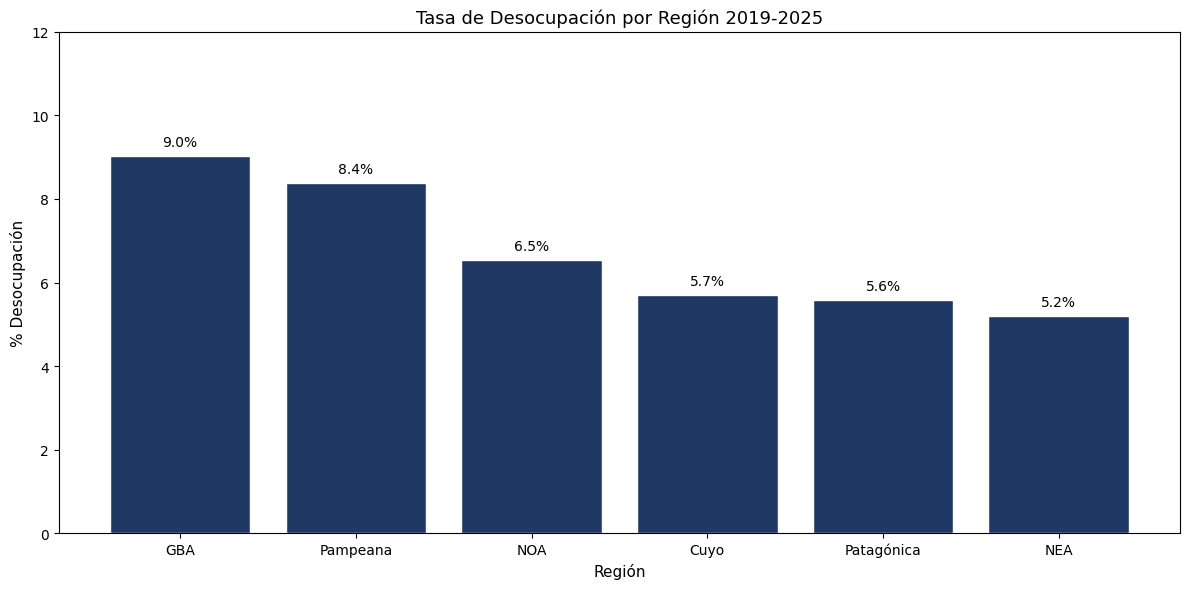

In [124]:
#Grafico
tasa_region = tasa_region.sort_values('tasa', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

barras = ax.bar(tasa_region['region'], tasa_region['tasa'],
                color='#1F3864', edgecolor='white')

# Etiquetas en cada barra
for barra in barras:
    alto = barra.get_height()
    ax.annotate(f'{alto:.1f}%',
                xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=10)

ax.set_title('Tasa de Desocupación por Región 2019-2025', fontsize=13)
ax.set_xlabel('Región', fontsize=11)
ax.set_ylabel('% Desocupación', fontsize=11)
ax.set_ylim(0, 12)


plt.tight_layout()
plt.savefig('grafico_regional.png', dpi=150, bbox_inches='tight')
plt.show()

In [125]:
# Exportar CSV limpio
#df_total.to_csv('/content/drive/MyDrive/INDEC/eph_limpio.csv', index=False)
#print("✅ CSV exportado correctamente")
#print(f"Filas: {len(df_total):,}")
#print(f"Columnas: {df_total.columns.tolist()}")